<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Bootcamp de Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Projeto 2 · Do modelo treinado ao vídeo de outra origem</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# O que acontece quando mudam as imagens?

O Notebook 02 usa o **QFDet** com pesos treinados no **RGBTDronePerson** e imagens desse conjunto.
Este notebook compara essa versão com o QFDet treinado em **VTUAV-det**, sobre uma sequência de outra origem.
A arquitetura continua sendo QFDet, mas os dois checkpoints representam aprendizados diferentes.

O objetivo é identificar por que bons resultados em um conjunto podem não se repetir nas imagens de outra aplicação.
A atividade usa **pesos publicados**, examina as duas entradas e interpreta previsões reais já registradas.
A reexecução da inferência é opcional. Não há treinamento de rede nesta etapa.

**Modo padrão: visualização.** Com o kernel **Projeto 2 - EDA**, execute todas as células para assistir aos vídeos,
ver a figura de referência e refazer as contagens e o gráfico a partir dos registros. Esse modo não importa o QFDet,
não carrega pesos e não baixa imagens ou checkpoints. Os dois vídeos de 12 segundos também estão incorporados às
saídas salvas; algumas interfaces exigem marcar o notebook como confiável para reproduzir saídas HTML.
Os MP4 estão em `assets/video/`.

**Para executar novamente a rede:** prepare o ambiente do Notebook 02 conforme o [README](README.md), obtenha os
89 pares com `.venv-qfdet-cpu/bin/python suporte/preparar_dados.py --vtuav` na pasta `projeto-2`, selecione o kernel
**Projeto 2 - QFDet CPU** e altere `REEXECUTAR_INFERENCIA` para `True` na próxima célula. Reinicie o kernel e execute
todas as células. A preparação pode baixar o pacote oficial de **18,85 GB**; reserve **20 GB livres adicionais**.
Depois de conferir os 178 arquivos de imagem, uma célula poderá baixar o checkpoint de aproximadamente **485 MB**.
A inferência usa CPU e pode levar alguns minutos; as células não instalam bibliotecas.

## Localizar o material e escolher o modo

Mantenha `REEXECUTAR_INFERENCIA = False` para visualizar a comparação com os arquivos distribuídos no projeto.
A inferência opcional reutiliza o ambiente e o código oficial do Notebook 02. `suporte/qfdet_video.py` concentra
o download verificado e a compatibilidade do checkpoint; a preparação das entradas continua explícita nas células.
O código abaixo aceita abrir o notebook na pasta do projeto ou na raiz do repositório.

In [1]:
from pathlib import Path

REEXECUTAR_INFERENCIA = False
PROJETO = Path.cwd()
if not (PROJETO / "suporte/qfdet_video.py").is_file():
    PROJETO = PROJETO / "projeto-2"
FONTE = PROJETO / "codigo/qfdet"
DADOS = PROJETO / "dados/vtuav-demo/pedestrian_043"
VIDEOS = PROJETO / "assets/video"

## Ferramentas para a comparação

A comparação usa as bibliotecas dos notebooks anteriores. `Video(..., embed=True)` incorpora os bytes de um MP4 à saída salva
no próprio notebook. Isso aumenta o tamanho do arquivo, mas permite levar a demonstração junto com o material.

In [2]:
%matplotlib inline
import json
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle
from IPython.display import Video, display, Image as ImagemIPython
plt.rcParams.update({"font.family": "sans-serif", "font.size": 11, "figure.dpi": 120})

Matplotlib is building the font cache; this may take a moment.


## De onde veio esse outro conjunto?

**VTUAV** foi apresentado por Pengyu Zhang, Jie Zhao, Dong Wang, Huchuan Lu e Xiang Ruan na CVPR 2022,
no artigo *Visible-Thermal UAV Tracking: A Large-Scale Benchmark and New Baseline*. O conjunto original reúne
500 sequências e 1.664.549 pares RGB e térmico, aproximadamente 1,7 milhão, divididos em 250 sequências de
treinamento e 250 de teste. Seu objetivo principal é o **rastreamento**: acompanhar um alvo ao longo do tempo.
[Projeto e downloads oficiais](https://zhang-pengyu.github.io/DUT-VTUAV/).

As imagens foram capturadas com um drone DJI Matrice 300 RTK e uma câmera Zenmuse H20T, a 30 quadros por
segundo. Os pares distribuídos têm 1920 × 1080 pixels. A imagem térmica foi capturada em resolução menor
e redimensionada no registro entre sensores; ter o mesmo tamanho final não significa ter a mesma quantidade
de detalhe original. [Artigo VTUAV, aquisição e registro](https://arxiv.org/html/2204.04120v1).

As duas câmeras observam a mesma cena. O registro aproxima suas geometrias, mas não garante alinhamento
perfeito em todos os objetos e instantes. A imagem térmica usada aqui é uma representação em intensidades,
não um mapa de temperaturas em graus Celsius.

**VTUAV é um conjunto de dados, não o nome do detector desta atividade.** O artigo original propõe um método de
rastreamento chamado HMFT. Esta atividade usa a implementação do **QFDet** dos notebooks anteriores.

## De rastreamento para detecção: VTUAV-det

Os autores do QFDet selecionaram sequências com pessoas no VTUAV, amostraram um quadro a cada 50 e produziram
novas anotações para **detecção de pessoas**. Essa adaptação se chama **VTUAV-det**: são 11.392 pares de treino
e 5.378 pares de teste. Essas quantidades se referem à versão de detecção, não aos 1,7 milhão de pares do acervo original.
[Descrição oficial da adaptação](https://nnnnerd.github.io/RGBTDronePerson/).

Rastrear um alvo e localizar todas as pessoas de uma imagem são tarefas diferentes. Por isso, não se deve
tratar automaticamente as anotações originais de rastreamento como uma referência completa para avaliar um detector.
No VTUAV-det, a classe de interesse é `person` e as caixas usam o referencial **térmico**.
[Artigo do QFDet, seção de experimentos](https://doi.org/10.1016/j.isprsjprs.2023.08.016).

Neste notebook, o trecho vem dos pares originais da sequência **`pedestrian_043`**. A demonstração usa
um pequeno recorte para observar o comportamento das duas versões treinadas no mesmo vídeo;
não reproduz as métricas publicadas sobre todo o VTUAV-det.

## Por que as imagens próprias podem ser diferentes?

O treinamento ajusta os parâmetros a partir dos exemplos disponíveis. Esse aprendizado pode se transferir
para outras cenas, mas a transferência precisa ser verificada. **Mudança de domínio** é uma mudança
nas condições ou na distribuição das imagens entre os dados conhecidos e os dados de uso.

Ao instalar o modelo em outro drone, várias condições podem mudar. A altura de voo pode mudar o tamanho aparente de uma
pessoa; o ângulo de visão muda sua aparência; outro sensor térmico produz intensidades e detalhes diferentes.
Iluminação, clima, compressão, movimento, oclusões e o alinhamento entre as câmeras também podem mudar.

Isso não torna automaticamente o modelo ruim, nem significa que toda troca de câmera exige treinamento.
Significa que **o nome da arquitetura e um resultado publicado não substituem o teste nas condições da aplicação**.
Antes de decidir sobre novos dados ou ajuste dos pesos, é necessário examinar exemplos representativos da aplicação.

## O que permanece e o que muda nesta comparação

| Aspecto | Versão do Notebook 02 | Versão para VTUAV-det |
|:--|:--|:--|
| Arquitetura | QFDet | QFDet |
| Aprendizado do checkpoint | RGBTDronePerson | VTUAV-det |
| Imagens desta comparação | Os mesmos 89 pares do VTUAV | Os mesmos 89 pares do VTUAV |
| Entradas | RGB e térmico | RGB e térmico |
| Classes interpretadas | `person`, `rider`, `crowd` | `person` |
| Limiar para exibir caixas | 0,30 | 0,30 |
| Preparação e regras de inferência | Configuração RGBTDronePerson | Configuração VTUAV |

Cada checkpoint deve ser usado com sua configuração correspondente. As versões têm normalização diferente
por sensor e limiares IoU de NMS diferentes (0,30 e 0,50). A opção `reweight` também difere (`False` e `True`),
mas atua na ponderação das perdas durante o **treinamento**; ela não altera diretamente o percurso de inferência.
A comparação envolve **duas versões completas de inferência**. O resultado não isola o efeito dos pesos,
do conjunto de treinamento ou de uma única opção de processamento.

A comparação numérica conta somente previsões da classe `person` com score a partir de 0,30.
No primeiro vídeo, `rider` e `crowd` também aparecem quando previstos; essas saídas mantêm seus nomes originais.

## Ler os registros e conferir o mesmo trecho

Os vídeos foram produzidos a partir de inferências reais, registradas em JSON. Os registros incluem o índice temporal,
as previsões e os hashes das imagens de cada par. Um hash permite conferir a identidade de um arquivo.
A verificação dos MP4 confirma a correspondência entre cada vídeo e a configuração utilizada.

In [3]:
referencia = json.loads((VIDEOS / "previsoes-referencia.json").read_text())
registros = referencia["registros"]
LIMIAR = referencia["limiar"]
assert len(registros) == 89 and LIMIAR == 0.30
for nome, esperado in referencia["videos_sha256"].items():
    arquivo = VIDEOS / f"demo-{nome}.mp4"
    assert hashlib.sha256(arquivo.read_bytes()).hexdigest() == esperado
print("Sequência:", referencia["sequencia"])
print("Pares reais:", len(registros), "| Limiar:", LIMIAR)

Sequência: pedestrian_043
Pares reais: 89 | Limiar: 0.3


## Conferir se a inferência foi solicitada

A rede só será executada quando `REEXECUTAR_INFERENCIA` for `True` **e** os 178 arquivos esperados estiverem presentes.
Se faltar alguma imagem, continuamos no modo de visualização e informamos como preparar o recorte.
A presença dos arquivos será conferida antes de qualquer download de checkpoint ou importação do detector;
os hashes serão verificados antes da inferência.

In [4]:
arquivos_vtuav = [DADOS / sensor / f"{r['frame']:06d}.jpg"
                  for r in registros for sensor in ("visible", "thermal")]
faltantes = [arquivo for arquivo in arquivos_vtuav if not arquivo.is_file()]
EXECUTAR_INFERENCIA = REEXECUTAR_INFERENCIA and not faltantes
if REEXECUTAR_INFERENCIA and faltantes:
    print(f"Faltam {len(faltantes)} de {len(arquivos_vtuav)} imagens. Mantido o modo visualização.")
    print("Prepare o recorte: .venv-qfdet-cpu/bin/python suporte/preparar_dados.py --vtuav")
    print("O pacote de origem tem 18,85 GB. Depois, reinicie o kernel QFDet e execute tudo.")
print("Modo:", "inferência em CPU" if EXECUTAR_INFERENCIA else "visualização pelos registros")

Modo: visualização pelos registros


## Primeiro vídeo: pesos do Notebook 02 em imagens do VTUAV

Este é o checkpoint **RGBTDronePerson**, usado anteriormente, recebendo os pares do novo trecho.
Os três painéis mostram RGB, térmico e as previsões sobre a imagem térmica. **As duas entradas participam
da previsão**, embora as caixas sejam desenhadas somente sobre o térmico.

Observe se as caixas permanecem nos mesmos objetos entre os quadros. A legenda distingue
`P` (pessoa), `R` (`rider`) e `G` (grupo, `crowd`). A ausência de uma caixa significa ausência de previsão exibida
acima do limiar; não significa ausência de uma pessoa na cena.

In [5]:
display(Video(filename=str(VIDEOS / "demo-rgbtdroneperson.mp4"),
              embed=True, width=1100))

## Segundo vídeo: pesos treinados em VTUAV-det

O segundo vídeo apresenta o **mesmo trecho e os mesmos instantes**, com o checkpoint treinado em VTUAV-det e sua
configuração correspondente. O vídeo apresenta somente a classe `person`, mesmo que existam veículos na cena.

Observe as pessoas que recebem caixas, nas omissões, nas caixas sobrepostas e na estabilidade entre os quadros.
Uma quantidade maior de caixas não basta para declarar mais acertos: também pode incluir duplicações e erros.

In [6]:
display(Video(filename=str(VIDEOS / "demo-vtuav.mp4"),
              embed=True, width=1100))

## Como esses vídeos foram montados

O recorte cobre 12 segundos, com **89 pares reais** entre os quadros originais 0 e 357, a 30 fps na fonte.
Os intervalos entre pares variam de 0,1 a 0,4 segundo. Para apresentar a 10 fps, o vídeo mantém o último
par completo e suas previsões até chegar o próximo par disponível. São 120 quadros de apresentação,
mas apenas 89 pares diferentes processados pelo detector.

Não há interpolação de movimento, imagem térmica artificial nem combinação de sensores de instantes diferentes.
A amostragem foi limitada pela disponibilidade do download; os dois experimentos receberam exatamente os
mesmos arquivos. **A reprodução do MP4 não mede velocidade de inferência em tempo real.**

Também não há rastreador: a rede faz detecções independentes em cada par. Uma pessoa que aparece em vários
quadros pode gerar várias previsões; a soma delas não conta indivíduos únicos.

O recorte veio do pacote oficial [`train_ST_004.zip`](https://drive.google.com/file/d/1UdbUJlJaTB7loptBlBY2Jb47YVDIxrbj/view),
de 18.850.569.348 bytes. A lista de sequências fornecida com o QFDet coloca `pedestrian_043` em **Test**,
apesar do nome desse pacote. Essa divergência impede inferir a partição apenas pelo nome do ZIP.
Por isso e por usar somente um trecho, esta demonstração não é apresentada como benchmark ou prova de generalização.

## Os pesos correspondentes continuam disponíveis

O [repositório oficial do QFDet](https://github.com/NNNNerd/mmdet-rgbtdroneperson) publica checkpoints separados:

- [RGBTDronePerson, usado no Notebook 02](https://drive.google.com/file/d/1TuVXy_h0PxTK8qLY1MgqJTNiAumV8p0V/view).
- [VTUAV-det, usado neste notebook](https://drive.google.com/file/d/1Savf3oeiWek4eeXrvYLuaoBMoZW3nag8/view).

O arquivo utilizado é `epoch_11_qfdet_vtuav.pth`, a variante **QFDet** publicada pelos autores.
O arquivo tem aproximadamente 485 MB. Não é preciso baixar novamente os dados usados no treinamento para
carregar esse aprendizado e fazer inferência em pares compatíveis.

**A célula abaixo só executa no modo de inferência, com os 178 arquivos de imagem disponíveis.**
A função `baixar_peso` baixa da fonte oficial quando o arquivo está ausente e reutiliza o arquivo já baixado
quando ele passa na verificação SHA-256. O hash abaixo identifica a versão utilizada nesta demonstração;
não é uma assinatura publicada pelos autores. Links externos podem mudar ou atingir cotas. Se o download
falhar, a execução para, e o link oficial acima permite verificar o acesso.

In [7]:
if EXECUTAR_INFERENCIA:
    import sys
    sys.path.insert(0, str(PROJETO / "suporte"))
    from qfdet_video import baixar_peso, carregar_modelo
    URL_PESO = "https://drive.google.com/file/d/1Savf3oeiWek4eeXrvYLuaoBMoZW3nag8/view"
    SHA256_PESO = "0c6d399dfe902d7e3d57b6a3d62fc0ff9c286e656568a5c2d2cd4fd21923513a"
    PESO = PROJETO / "modelos/epoch_11_qfdet_vtuav.pth"
    baixar_peso(PESO, URL_PESO, SHA256_PESO)
    print("Checkpoint disponível:", PESO.name)

## Carregar o detector com a configuração VTUAV

A função abaixo lê [`qfdet_r50_fpn_1x_vtuav.py`](https://github.com/NNNNerd/mmdet-rgbtdroneperson/blob/a79210c283597294ded255028bb8fe16e1c241cd/qfdet_configs/qfdet_r50_fpn_1x_vtuav.py),
monta o QFDet e carrega os parâmetros ativos com `strict=True`, como no Notebook 02. A rede fica em modo de
avaliação na CPU. Isso prepara o comportamento de inferência; não calcula métricas e não altera os pesos.

Há uma particularidade do checkpoint publicado: os classificadores têm três canais físicos, mas os metadados
do VTUAV-det definem apenas a classe `person`. A estrutura é preservada para carregar os pesos corretamente, e
**somente `resultado[0]` é interpretado como pessoa**. As outras duas saídas não recebem os nomes `rider` e `crowd`.

O suporte também confere a correspondência com a configuração salva no checkpoint. Como no notebook anterior,
seis tensores de ramos de fusão inativos são desconsiderados apenas em memória; os parâmetros ativos são mantidos.
O arquivo original do checkpoint não é modificado.

In [8]:
if EXECUTAR_INFERENCIA:
    import torch
    torch.set_num_threads(4)
    modelo, config, verificacao = carregar_modelo(FONTE, PESO)
    from mmdet.datasets.pipelines import Compose
    preparar = Compose(config.test_pipeline)
    print("Modelo carregado:", config.model.type)
    print("Classe interpretada:", modelo.CLASSES)
    print("Normalização por sensor:", config.img_norm_cfg)

## Conferir os pares usados na inferência

Os arquivos RGB e térmico têm o mesmo nome em pastas diferentes. **No modo de inferência**, a verificação abaixo
confere os hashes de todas as imagens com os registros dos vídeos. Assim, a execução seguinte usa os mesmos 89 pares.
O recorte é obtido da fonte oficial por `.venv-qfdet-cpu/bin/python suporte/preparar_dados.py --vtuav`,
conforme o README. As imagens originais não acompanham o clone do repositório.

In [9]:
if EXECUTAR_INFERENCIA:
    for registro in registros:
        nome = f"{registro['frame']:06d}.jpg"
        for sensor in ("visible", "thermal"):
            imagem = DADOS / sensor / nome
            obtido = hashlib.sha256(imagem.read_bytes()).hexdigest()
            assert obtido == registro["sha256"][sensor]
    print("Pares conferidos:", len(registros))

## Preparar RGB e térmico e fazer uma previsão

Esta função repete o percurso do Notebook 02 para um par: leitura, resize, normalização por modalidade,
organização dos tensores e chamada do detector. As anotações não fazem parte da entrada.

As imagens 1920 × 1080 são redimensionadas para 640 × 360, preservando a proporção, e preenchidas até
640 × 384. `rescale=True` devolve as caixas no tamanho térmico original. O primeiro item do resultado
seleciona o único par do lote, e o segundo `[0]` seleciona a classe `person`.

In [10]:
if EXECUTAR_INFERENCIA:
    def detectar_pessoas(indice):
        nome = f"{indice:06d}.jpg"
        amostra = preparar(dict(img_info=dict(filename=nome), img_prefix=str(DADOS)))
        par = [item.data.unsqueeze(0) for item in amostra["img"][0]]
        metadados = amostra["img_metas"][0].data
        with torch.inference_mode():
            resultado = modelo(return_loss=False, rescale=True,
                               img=[par], img_metas=[[metadados]])[0]
        return resultado[0]

## Observar o primeiro quadro

No modo padrão, a célula lê as previsões salvas; no modo de inferência, executa a rede nesse par.
Em ambos os casos, seleciona as caixas com score a partir de 0,30. Cada linha contém os cantos
`[x1, y1, x2, y2]` em pixels e uma pontuação. O score não deve ser interpretado automaticamente como uma
probabilidade calibrada de acerto.

In [11]:
INDICE = registros[0]["frame"]
if EXECUTAR_INFERENCIA:
    caixas = detectar_pessoas(INDICE)
    termica = np.array(Image.open(DADOS / "thermal" / f"{INDICE:06d}.jpg"))
else:
    caixas = np.asarray(registros[0]["vtuav"]["person"], dtype=np.float32).reshape(-1, 5)
selecionadas = caixas[caixas[:, 4] >= LIMIAR]
print("Origem:", "inferência recalculada" if EXECUTAR_INFERENCIA else "registro salvo")
print("Previsões de pessoa exibidas:", len(selecionadas))
print(np.round(selecionadas, 2))

Origem: registro salvo
Previsões de pessoa exibidas: 5
[[3.24810e+02 6.62040e+02 3.53870e+02 7.36230e+02 8.30000e-01]
 [4.41530e+02 4.26630e+02 4.70540e+02 4.94860e+02 7.50000e-01]
 [1.66331e+03 7.33270e+02 1.68947e+03 8.16150e+02 7.20000e-01]
 [3.60240e+02 5.83330e+02 3.84330e+02 6.50460e+02 5.40000e-01]
 [1.67414e+03 7.42600e+02 1.70169e+03 8.24260e+02 4.30000e-01]]


## Mostrar as caixas no referencial térmico

A imagem abaixo permite pausar a análise em um único instante. O RGB também participou da previsão.
Essas coordenadas não são copiadas para o RGB, pois o registro entre os sensores é aproximado.

No modo padrão, exibimos a **figura de referência**, salva na produção da demonstração em
`assets/video/primeiro-quadro-vtuav.png`. No modo de inferência, desenhamos as caixas recém-calculadas
sobre a imagem térmica original. A primeira opção dispensa os dados brutos.

In [12]:
if EXECUTAR_INFERENCIA:
    plt.figure(figsize=(12, 6))
    plt.imshow(termica)
    for posicao, (x1, y1, x2, y2, score) in enumerate(sorted(selecionadas, key=lambda caixa: caixa[0])):
        plt.gca().add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, color="#00E5A8"))
        y_texto = y1 - 10 if posicao % 2 == 0 else y2 + 24
        plt.text(x1, y_texto, f"person {score:.2f}", color="#00E5A8", fontsize=8,
                 bbox=dict(facecolor="#202020", edgecolor="none", pad=0.3))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

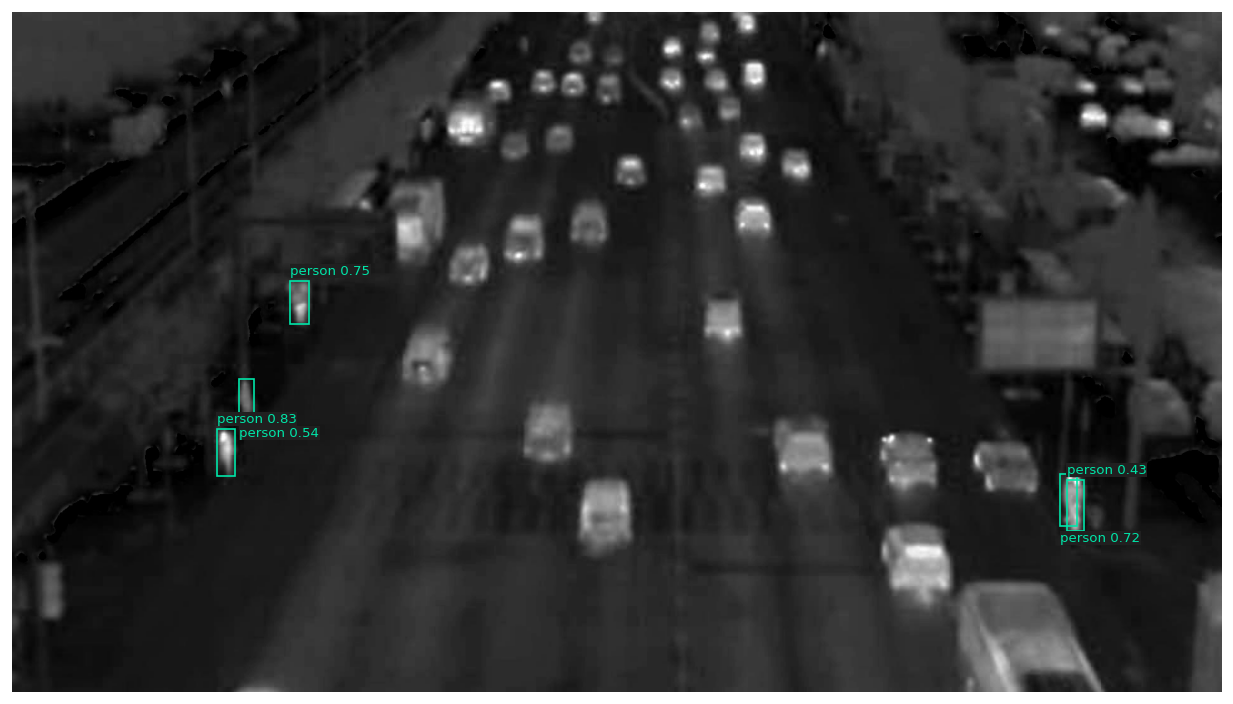

In [13]:
if not EXECUTAR_INFERENCIA:
    display(ImagemIPython(filename=str(VIDEOS / "primeiro-quadro-vtuav.png")))

## Repetir nos pares do trecho

No modo padrão, organizamos as previsões salvas dos 89 pares para a comparação.
No modo de inferência, o primeiro resultado é reutilizado, e a mesma função processa os demais 88 pares,
mantendo o modelo carregado. Isso repete a inferência VTUAV-det de todo o trecho;
o resultado RGBTDronePerson já registrado será usado na comparação.

Na CPU, aguarde alguns minutos. O tempo para produzir as previsões é diferente da duração de 12 segundos
do vídeo pronto. O processo não acrescenta rastreamento nem altera os pesos.

In [14]:
previsoes_vtuav = {r["frame"]: np.asarray(r["vtuav"]["person"]).reshape(-1, 5) for r in registros}
if EXECUTAR_INFERENCIA:
    previsoes_vtuav = {INDICE: caixas}
    for posicao, registro in enumerate(registros, start=1):
        indice = registro["frame"]
        if indice not in previsoes_vtuav:
            previsoes_vtuav[indice] = detectar_pessoas(indice)
        if posicao % 20 == 0 or posicao == len(registros):
            print("Pares processados:", posicao, "de", len(registros))

## Conferir a reprodução da demonstração

**Somente quando a inferência é reexecutada**, a verificação compara as previsões recalculadas com as registradas
na produção do vídeo, admitindo uma pequena tolerância numérica. Isso verifica a reprodução deste resultado,
não a correspondência com anotações humanas. Nenhum teste de acurácia é realizado por essa conferência.
Ler os registros no modo padrão não constitui uma nova validação da inferência.

In [15]:
if EXECUTAR_INFERENCIA:
    for registro in registros:
        calculadas = previsoes_vtuav[registro["frame"]]
        gravadas = np.asarray(registro["vtuav"]["person"], dtype=np.float32).reshape(-1, 5)
        assert calculadas.shape == gravadas.shape
        assert np.allclose(calculadas, gravadas, rtol=1e-4, atol=1e-3)
    print("Os 89 resultados reproduzem os registros do vídeo.")
else:
    print("Modo visualização: os registros foram lidos; a inferência não foi reexecutada.")

Modo visualização: os registros foram lidos; a inferência não foi reexecutada.


## Contar previsões, sem confundir com acertos

A contagem considera as caixas `person` que passaram pelo mesmo limiar em cada par. No RGBTDronePerson,
`rider` e `crowd` ficam fora dessa contagem. No VTUAV-det, usamos os registros salvos no modo padrão
ou as previsões recalculadas quando a inferência foi ativada. O gráfico seguinte usa a mesma origem.

In [16]:
def contar_pessoas(caixas):
    valores = np.asarray(caixas).reshape(-1, 5)
    return int((valores[:, 4] >= LIMIAR).sum())

tempos = [r["segundos"] for r in registros]
contagens_rgbt = np.array([contar_pessoas(r["rgbtdroneperson"]["person"]) for r in registros])
contagens_vtuav = np.array([contar_pessoas(previsoes_vtuav[r["frame"]]) for r in registros])
for nome, valores in [("RGBTDronePerson", contagens_rgbt), ("VTUAV-det", contagens_vtuav)]:
    print(nome, "| Pares com pessoa prevista:", int((valores > 0).sum()), "de", len(valores))
    print("Mínimo e máximo de caixas por par:", int(valores.min()), int(valores.max()))

RGBTDronePerson | Pares com pessoa prevista: 15 de 89
Mínimo e máximo de caixas por par: 0 2
VTUAV-det | Pares com pessoa prevista: 89 de 89
Mínimo e máximo de caixas por par: 4 8


## Comparar a variação ao longo do tempo

O eixo vertical conta **previsões exibidas por par**, e não o número verdadeiro de pessoas presentes.
Cada ponto corresponde a um dos pares efetivamente processados; as linhas só ajudam a acompanhar a sequência.

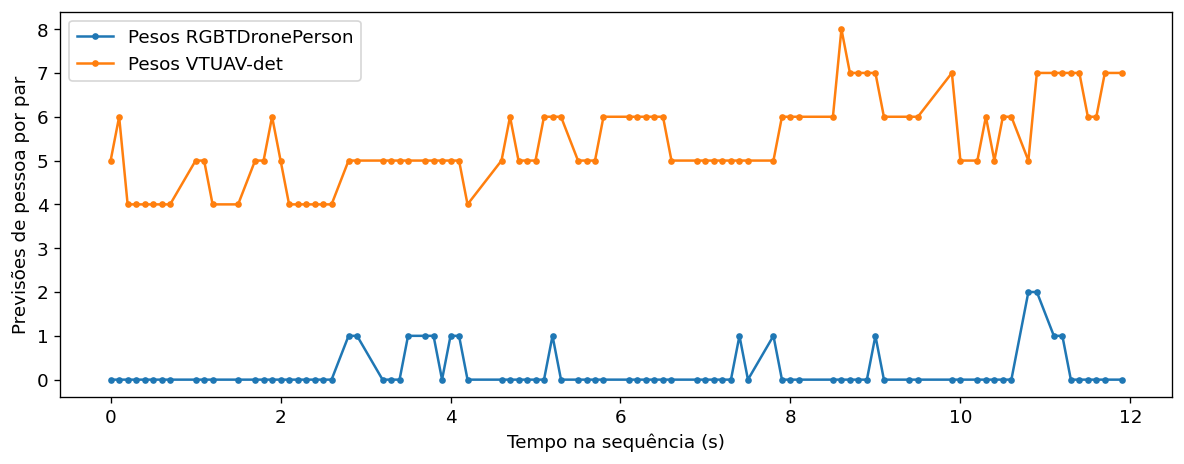

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(tempos, contagens_rgbt, ".-", label="Pesos RGBTDronePerson")
plt.plot(tempos, contagens_vtuav, ".-", label="Pesos VTUAV-det")
plt.xlabel("Tempo na sequência (s)")
plt.ylabel("Previsões de pessoa por par")
plt.legend()
plt.tight_layout()
plt.show()

## Como interpretar o que observamos

Neste recorte e com limiar 0,30, a versão RGBTDronePerson produziu previsões de `person` em **15 dos 89 pares**,
com zero a duas caixas por par. A versão VTUAV-det produziu previsões dessa classe em **todos os 89 pares**,
com quatro a oito caixas por par. No primeiro vídeo também surgem classificações `crowd`.

Isso mostra comportamentos diferentes sobre as mesmas imagens. **15 de 89 não é recall**, e 89 de 89 não
significa que todas as pessoas foram detectadas. Os denominadores aqui são pares de imagens, não objetos
anotados. Mais caixas também podem significar duplicações ou falsos positivos.

Os resultados são compatíveis com a preocupação sobre mudança de domínio, mas este experimento não demonstra
uma causa única. Mudam os dados que originaram os pesos, as classes e partes da configuração. Também não há
comparação entre RGB isolado e RGB com térmico; portanto, o experimento não mede o ganho da fusão entre sensores.

A comparação formal de qualidade exige um conjunto de teste definido, representativo da aplicação,
com anotações de detecção, critérios para associar previsões a objetos e métricas calculadas no mesmo protocolo.
Escolher apenas um trecho favorável não permite estender a conclusão para todo cenário de voo.

## Aplicação às imagens de outro drone

A primeira verificação é se o checkpoint prevê as classes de interesse e se a entrada respeita a preparação
esperada. Em dados RGB e térmicos, isso inclui emparelhamento temporal, ordem dos sensores, escala e normalização.
Um erro nessas etapas pode parecer uma falha de aprendizado.

A etapa seguinte testa exemplos das condições reais: diferentes alturas, horários, fundos e tamanhos de pessoa.
Anotar uma amostra permite separar impressões visuais de erros medidos. Se os resultados forem insuficientes,
é possível avaliar outro checkpoint apropriado, adaptação ou ajuste fino com novos dados.

**Não basta escolher uma arquitetura conhecida e carregar qualquer peso.** É necessário verificar se o conjunto
formado por modelo, pesos, processamento e classes atende aos dados da aplicação. Usar pesos publicados
é um ponto de partida que permite executar a demonstração sem treinamento adicional.

## Perguntas para discutir

- Uma pessoa está visível, mas não há caixa: quais etapas da aplicação devem ser verificadas antes de retreinar?
- Duas caixas aparecem sobre a mesma pessoa: por que a contagem de previsões não é uma contagem de pessoas?
- Baixar o limiar faz aparecer mais caixas. Como saber se melhorou a qualidade?
- Que imagens do seu drone seriam necessárias para avaliar as condições em que ele realmente vai operar?

## Fontes e reprodução

- [VTUAV: projeto, artigo e downloads](https://zhang-pengyu.github.io/DUT-VTUAV/).
- [Artigo VTUAV, CVPR 2022](https://arxiv.org/html/2204.04120v1).
- [RGBTDronePerson e descrição do VTUAV-det](https://nnnnerd.github.io/RGBTDronePerson/).
- [Drone-based RGBT tiny person detection, 2023](https://doi.org/10.1016/j.isprsjprs.2023.08.016).
- [Código e checkpoints QFDet](https://github.com/NNNNerd/mmdet-rgbtdroneperson).
- [Lista oficial de sequências VTUAV-det](https://drive.google.com/file/d/1ekwegneAPmrFFyU0Ku2-TEucvA_6jPIP/view).

Código de referência: commit `a79210c283597294ded255028bb8fe16e1c241cd`. As fontes foram
consultadas em 22/09/2026. Os vídeos incorporados preservam as demonstrações mesmo se o acesso externo mudar.
Para reexecutar a inferência, prepare os arquivos e o kernel QFDet descritos no README e ative `REEXECUTAR_INFERENCIA`.
O modo padrão reconstrói a comparação pelos registros, sem baixar o checkpoint.